# 2Q iSWAP — asymmetric anharmonicities  (warm-start for 3Q)

Solves the 4-dim 2Q resonant-exchange iSWAP problem with **per-qubit anharmonicities**:

- `η_1 / 2π = −183.6 MHz`  (qubit 1)
- `η_2 / 2π = −181.2 MHz`  (qubit 2)

Different from the symmetric `iswap_pulse_construction.ipynb` (which used η = −170 MHz for both). Each qubit gets its **own** `SpectralLeakageConstraintIQ` at its own `|η_i|` so the optimizer suppresses each qubit's 1Q leakage channel independently.

The resulting 4-dim trajectory is intended as a warm-start for a subsequent 3-qubit optimization. Save format is compatible with the polish-script loader.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
piccolo_path       = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop([
    Pkg.PackageSpec(path = piccolo_path),
    Pkg.PackageSpec(path = directtrajopt_path),
])
Pkg.instantiate()

using Piccolo, FFTW, CairoMakie, Printf, LinearAlgebra, Random, SparseArrays, JLD2
using DirectTrajOpt.Constraints: AbstractNonlinearConstraint
using DirectTrajOpt.CommonInterface

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational`
   Resolving package versions...
    Updating `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/Project.toml`
  [c823fa1f] ~ DirectTrajOpt v0.8.10 `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/DirectTrajOpt.jl` ⇒ v0.8.10 `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/DirectTrajOpt.jl`
  [c4671d76] ~ Piccolo v1.8.0 `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Piccolo.jl` ⇒ v1.8.0 `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Piccolo.jl`
    Updating `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/Manifest.toml`
  [c823fa1f] ~ DirectTrajOpt v0.8.10 `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/DirectTrajOpt.jl` ⇒ v0.8.10 `~/Lib

## Constants

Per-qubit anharmonicities are the only physical change from the symmetric notebook.

In [2]:
# --- timing layout ---
const T_TOTAL_NS    = 250.0
const T_PULSE_NS    = 200.0
const T_RISE        = 25.0
const T_FALL        = T_RISE + T_PULSE_NS
const T_EDGE_MARK   = 10.0
const T_FLAT_NS     = T_FALL - T_RISE - 2 * T_EDGE_MARK    # 180 ns
const N_FINE        = 16384
const dt_fine       = T_TOTAL_NS / N_FINE

# --- per-qubit anharmonicities (asymmetric) ---
const η_1_MHz       = 183.6                  # qubit 1
const η_2_MHz       = 181.2                  # qubit 2
const η_1_rad_pos   = 2π * η_1_MHz * 1e-3    # +|η_1| in rad/ns, used for spectral-constraint frequency
const η_2_rad_pos   = 2π * η_2_MHz * 1e-3
const η_1_rad_neg   = -2π * η_1_MHz * 1e-3   # transmon convention (η < 0), used for H_anh
const η_2_rad_neg   = -2π * η_2_MHz * 1e-3

# --- envelope filter ---
const B_AWG_MHz     = 250.0
const σ_f_anh_MHz   = 100.0                  # η-killer Gaussian width
const σ_f_AWG_MHz   = B_AWG_MHz / sqrt(log(2))

# --- drive / coupling ---
const g_max_MHz         = 2.0
const g_max_rad_per_ns  = 2π * g_max_MHz * 1e-3
const g_flat            = g_max_rad_per_ns
const g_max_env         = 1.0

# --- MW + optimization ---
const a_bound_MW    = 2π * 0.01
const F_THRESHOLD   = 0.9999
const Q_R           = 1e2
const ε_MAX         = 1e-2
const N_KNOTS       = 15
const N_SAMPLES_OPT = 300
const Δt_FLAT       = T_FLAT_NS / (N_KNOTS - 1)
const NUM_ITER      = 1000
const SEED          = 42

const RUN_TAG = "asym_2lvl_4dim_geff2MHz_200ns_eta1_$(Int(round(η_1_MHz)))_eta2_$(Int(round(η_2_MHz)))"

@printf("η_1 / 2π = %.1f MHz   (rad/ns: +%.4f, neg = %.4f)\n", η_1_MHz, η_1_rad_pos, η_1_rad_neg)
@printf("η_2 / 2π = %.1f MHz   (rad/ns: +%.4f, neg = %.4f)\n", η_2_MHz, η_2_rad_pos, η_2_rad_neg)
@printf("Filter G(|η_1|) = %.3e   G(|η_2|) = %.3e\n",
    exp(-η_1_MHz^2 / (2 * σ_f_anh_MHz^2)),
    exp(-η_2_MHz^2 / (2 * σ_f_anh_MHz^2)))

η_1 / 2π = 183.6 MHz   (rad/ns: +1.1536, neg = -1.1536)
η_2 / 2π = 181.2 MHz   (rad/ns: +1.1385, neg = -1.1385)
Filter G(|η_1|) = 1.854e-01   G(|η_2|) = 1.937e-01


## Filtered g_eff envelope

In [3]:
const ts_env = collect(LinRange(0.0, T_TOTAL_NS, N_FINE))

function gaussian_lowpass(g_t::AbstractVector, dt_ns::Float64, σ_MHz::Float64)
    N      = length(g_t)
    G      = fft(g_t)
    fs_MHz = fftfreq(N, 1.0 / dt_ns) .* 1e3
    mask   = exp.(-0.5 .* (fs_MHz ./ σ_MHz).^2)
    return real.(ifft(G .* mask))
end

g_square      = Float64[(T_RISE ≤ t ≤ T_FALL) ? g_max_env : 0.0 for t in ts_env]
g_after_anh   = gaussian_lowpass(g_square,    dt_fine, σ_f_anh_MHz)
g_after_AWG   = gaussian_lowpass(g_after_anh, dt_fine, σ_f_AWG_MHz)
g_phys_env    = g_after_AWG .* g_max_rad_per_ns

const cumul   = cumsum(g_phys_env) .* dt_fine
const total_g = cumul[end]

flat_start_idx = argmin(abs.(ts_env .- (T_RISE + T_EDGE_MARK)))
flat_end_idx   = argmin(abs.(ts_env .- (T_FALL - T_EDGE_MARK)))

A_rise        = cumul[flat_start_idx]
A_fall        = cumul[end] - cumul[flat_end_idx]
A_flat_drift  = cumul[flat_end_idx] - cumul[flat_start_idx]

@printf("∫ g_eff dt total = %.4f rad = %.3f · (π/4)\n", total_g, total_g / (π/4))
@printf("A_rise = %.4f rad,  A_fall = %.4f rad,  A_flat = %.4f rad\n", A_rise, A_fall, A_flat_drift)

∫ g_eff dt total = 2.5130 rad = 3.200 · (π/4)
A_rise = 0.1258 rad,  A_fall = 0.1256 rad,  A_flat = 2.2617 rad


## Pauli operators (2Q computational subspace)

In [4]:
const XX = operator_from_string("XX")
const YY = operator_from_string("YY")
const XI = operator_from_string("XI")
const YI = operator_from_string("YI")
const IX = operator_from_string("IX")
const IY = operator_from_string("IY")
const ZI = operator_from_string("ZI")
const IZ = operator_from_string("IZ")
const ZZ = operator_from_string("ZZ")

4×4 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im   0.0+0.0im  -0.0+0.0im
 0.0+0.0im   0.0+0.0im  -1.0+0.0im  -0.0+0.0im
 0.0+0.0im  -0.0+0.0im  -0.0+0.0im   1.0-0.0im

## Edge unitaries and flat-region target

Closed-form `(XX+YY)` rotations from the integrated edge areas. Same construction as the symmetric notebook.

In [5]:
V_rise   = exp(-im * A_rise * (XX + YY))
V_fall   = exp(-im * A_fall * (XX + YY))
U_iSWAP  = exp(-im * (π/4) * (XX + YY))
U_goal   = V_fall' * U_iSWAP * V_rise'

F_check  = abs2(tr(U_iSWAP' * (V_fall * U_goal * V_rise))) / 16
@printf("F(V_fall · U_goal · V_rise, U_iSWAP) = %.10f\n", F_check)

F(V_fall · U_goal · V_rise, U_iSWAP) = 1.0000000000


## SpectralLeakageConstraintIQ — per-qubit IQ-pair version

Identical to `iswap_pulse_construction.ipynb`. Each qubit's IQ pair (`u_X1, u_Y1`) or (`u_X2, u_Y2`) is constrained at its own qubit's `|η|` frequency.

In [6]:
struct SpectralLeakageConstraintIQ <: AbstractNonlinearConstraint
    name::Symbol
    i_X::Int
    i_Y::Int
    ω::Float64
    ε_max::Float64
    times_t::Vector{Float64}
    Δts::Vector{Float64}
    cosωt::Vector{Float64}
    sinωt::Vector{Float64}
    dim::Int
    equality::Bool
end

function SpectralLeakageConstraintIQ(name::Symbol, i_X::Int, i_Y::Int,
                                     ω::Float64, ε_max::Float64, traj)
    times = get_times(traj)
    Δts   = get_timesteps(traj)
    return SpectralLeakageConstraintIQ(name, i_X, i_Y, ω, ε_max,
        Vector{Float64}(times), Vector{Float64}(Δts),
        cos.(ω .* times), sin.(ω .* times),
        1, false)
end

function _ReIm_IQ(c::SpectralLeakageConstraintIQ, u::AbstractMatrix)
    Re_sum = zero(eltype(u)); Im_sum = zero(eltype(u))
    @inbounds for k in 1:length(c.times_t)
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        uX = u[c.i_X, k]; uY = u[c.i_Y, k]
        Re_sum += Δt_k * (uX * cos_k + uY * sin_k)
        Im_sum += Δt_k * (uY * cos_k - uX * sin_k)
    end
    return Re_sum, Im_sum
end

function CommonInterface.evaluate!(values::AbstractVector,
                                   c::SpectralLeakageConstraintIQ, traj)
    u = traj[c.name]
    Re_sum, Im_sum = _ReIm_IQ(c, u)
    values[1] = Re_sum^2 + Im_sum^2 - c.ε_max
    return nothing
end

function CommonInterface.eval_jacobian(c::SpectralLeakageConstraintIQ, traj)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂g    = spzeros(c.dim, Z_dim)
    u     = traj[c.name]
    Re_sum, Im_sum = _ReIm_IQ(c, u)
    comps = traj.components[c.name]
    @inbounds for k in 1:traj.N
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        idxX = traj.dim * (k - 1) + comps[c.i_X]
        idxY = traj.dim * (k - 1) + comps[c.i_Y]
        ∂g[1, idxX] = 2 * Δt_k * (Re_sum * cos_k - Im_sum * sin_k)
        ∂g[1, idxY] = 2 * Δt_k * (Re_sum * sin_k + Im_sum * cos_k)
    end
    return ∂g
end

function CommonInterface.eval_hessian_of_lagrangian(c::SpectralLeakageConstraintIQ,
                                                    traj, μ::AbstractVector)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂²g   = spzeros(Z_dim, Z_dim)
    comps = traj.components[c.name]
    a = zeros(Z_dim); b = zeros(Z_dim)
    @inbounds for k in 1:traj.N
        idxX = traj.dim * (k - 1) + comps[c.i_X]
        idxY = traj.dim * (k - 1) + comps[c.i_Y]
        a[idxX] = c.Δts[k] * c.cosωt[k]
        a[idxY] = c.Δts[k] * c.sinωt[k]
        b[idxX] = -c.Δts[k] * c.sinωt[k]
        b[idxY] =  c.Δts[k] * c.cosωt[k]
    end
    nzs = findall(!iszero, a) ∪ findall(!iszero, b)
    for i in nzs, j in nzs
        v = 2 * μ[1] * (a[i]*a[j] + b[i]*b[j])
        if v != 0.0
            ∂²g[i, j] = v
        end
    end
    return ∂²g
end

println("SpectralLeakageConstraintIQ defined.")

SpectralLeakageConstraintIQ defined.


## Flat-region optimization problem

The only difference from the symmetric notebook is that the two `SpectralLeakageConstraintIQ` instances now use **different** ω values (qubit 1's and qubit 2's anharmonicities).

In [7]:
function H_flat_gate(u, t)
    H = g_flat * (XX + YY)
    H += u[1] * XI + u[2] * YI
    H += u[3] * IX + u[4] * IY
    return H
end

H_vars = Function[
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

drive_bounds = fill(a_bound_MW, 4)

varsys = VariationalQuantumSystem(
    H_flat_gate, H_vars, 4, drive_bounds; time_dependent = true,
)
@printf("varsys: levels=%d  n_drives=%d  n_vars=%d\n",
    varsys.levels, varsys.n_drives, length(varsys.G_vars))

varsys: levels=4  n_drives=4  n_vars=3


In [8]:
Random.seed!(SEED)
controls_init = 2 .* a_bound_MW .* rand(4, N_SAMPLES_OPT) .- a_bound_MW
times_init    = collect(LinRange(0.0, T_FLAT_NS, N_SAMPLES_OPT))
du_init       = zeros(4, N_SAMPLES_OPT)
pulse_init    = CubicSplinePulse(controls_init, du_init, times_init)

qcp = VariationalSplinePulseProblem(
    varsys, pulse_init, U_goal, N_KNOTS;
    Q                     = 0.0,
    Q_r                   = Q_R,
    R                     = 1e-3,
    du_bound              = Inf,
    Δt_bounds             = (Δt_FLAT, Δt_FLAT),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_THRESHOLD, get_trajectory(qcp)))

traj = get_trajectory(qcp)

# Per-qubit spectral leakage constraints — TWO different ω
push!(qcp.prob.constraints,
    SpectralLeakageConstraintIQ(:u, 1, 2, η_1_rad_pos, ε_MAX, traj))   # qubit 1 at |η_1|
push!(qcp.prob.constraints,
    SpectralLeakageConstraintIQ(:u, 3, 4, η_2_rad_pos, ε_MAX, traj))   # qubit 2 at |η_2|

@printf("\nProblem built.\n")
@printf("  N_KNOTS = %d   Δt = %.4f ns\n", N_KNOTS, Δt_FLAT)
@printf("  ε_max   = %.0e per qubit\n", ε_MAX)
@printf("  ω_1     = 2π · %.1f MHz   (qubit 1, η_1)\n", η_1_MHz)
@printf("  ω_2     = 2π · %.1f MHz   (qubit 2, η_2)\n", η_2_MHz)
@printf("  F_thr   = %.4f\n", F_THRESHOLD)
@printf("  Q_r     = %.0e\n", Q_R)

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

Problem built.
  N_KNOTS = 15   Δt = 12.8571 ns
  ε_max   = 1e-02 per qubit
  ω_1     = 2π · 183.6 MHz   (qubit 1, η_1)
  ω_2     = 2π · 181.2 MHz   (qubit 2, η_2)
  F_thr   = 0.9999
  Q_r     = 1e+02


## Solve and save

In [9]:
const IPOPT_LOG = joinpath(@__DIR__, "ipopt_$(RUN_TAG).log")
const TRAJ_PATH = joinpath(@__DIR__, "traj_$(RUN_TAG).jld2")

println("Solving asymmetric-η 2Q iSWAP...")
println("  IPOPT log:  $IPOPT_LOG")
println("  Trajectory: $TRAJ_PATH")

t0 = time()
try
    solve!(qcp; max_iter = NUM_ITER, print_level = 5,
        options = IpoptOptions(
            eval_hessian    = false,
            output_file     = IPOPT_LOG,
            constr_viol_tol = 1e-8,
            tol             = 1e-8,
            acceptable_tol  = 1e-8,
        ))
catch e
    e isa InterruptException || rethrow(e)
    println("Interrupted")
end
@printf("solve wall: %.1f s\n", time() - t0)

traj_robust  = get_trajectory(qcp)
U_flat_final = iso_vec_to_operator(traj_robust[:Ũ⃗][:, end])
F_flat       = abs2(tr(U_goal' * U_flat_final)) / 16
U_full       = V_fall * U_flat_final * V_rise
F_full       = abs2(tr(U_iSWAP' * U_full)) / 16

@printf("\nF(U_flat, U_goal)              = %.8f   (1−F = %.3e)\n", F_flat, 1 - F_flat)
@printf("F(V_fall·U_flat·V_rise, U_iSWAP) = %.8f   (1−F = %.3e)\n", F_full, 1 - F_full)

@save TRAJ_PATH traj_robust U_goal U_iSWAP V_rise V_fall A_rise A_fall A_flat_drift g_max_MHz η_1_MHz η_2_MHz T_FLAT_NS T_RISE T_FALL T_EDGE_MARK
@printf("\nSaved: %s\n", TRAJ_PATH)

Solving asymmetric-η 2Q iSWAP...
  IPOPT log:  /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/ipopt_asym_2lvl_4dim_geff2MHz_200ns_eta1_184_eta2_181.log
  Trajectory: /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/traj_asym_2lvl_4dim_geff2MHz_200ns_eta1_184_eta2_181.jld2
    initializing optimizer...
      building evaluator: 2 integrators, 4 nonlinear constraints
      dynamics constraints: 2240, nonlinear constraints: 339
        integrator 1 jacobian structure: 0.122s
        integrator 2 jacobian structure: 0.044s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.533s
        constraint 2 (NonlinearKnotPointConstraint) jacobian structure: 0.621s
        constraint 3 (SpectralLeakageConstraintIQ) jacobian structure: 0.022s
        constraint 4 (SpectralLeakageConstraintIQ) jacobian structure: 0.00

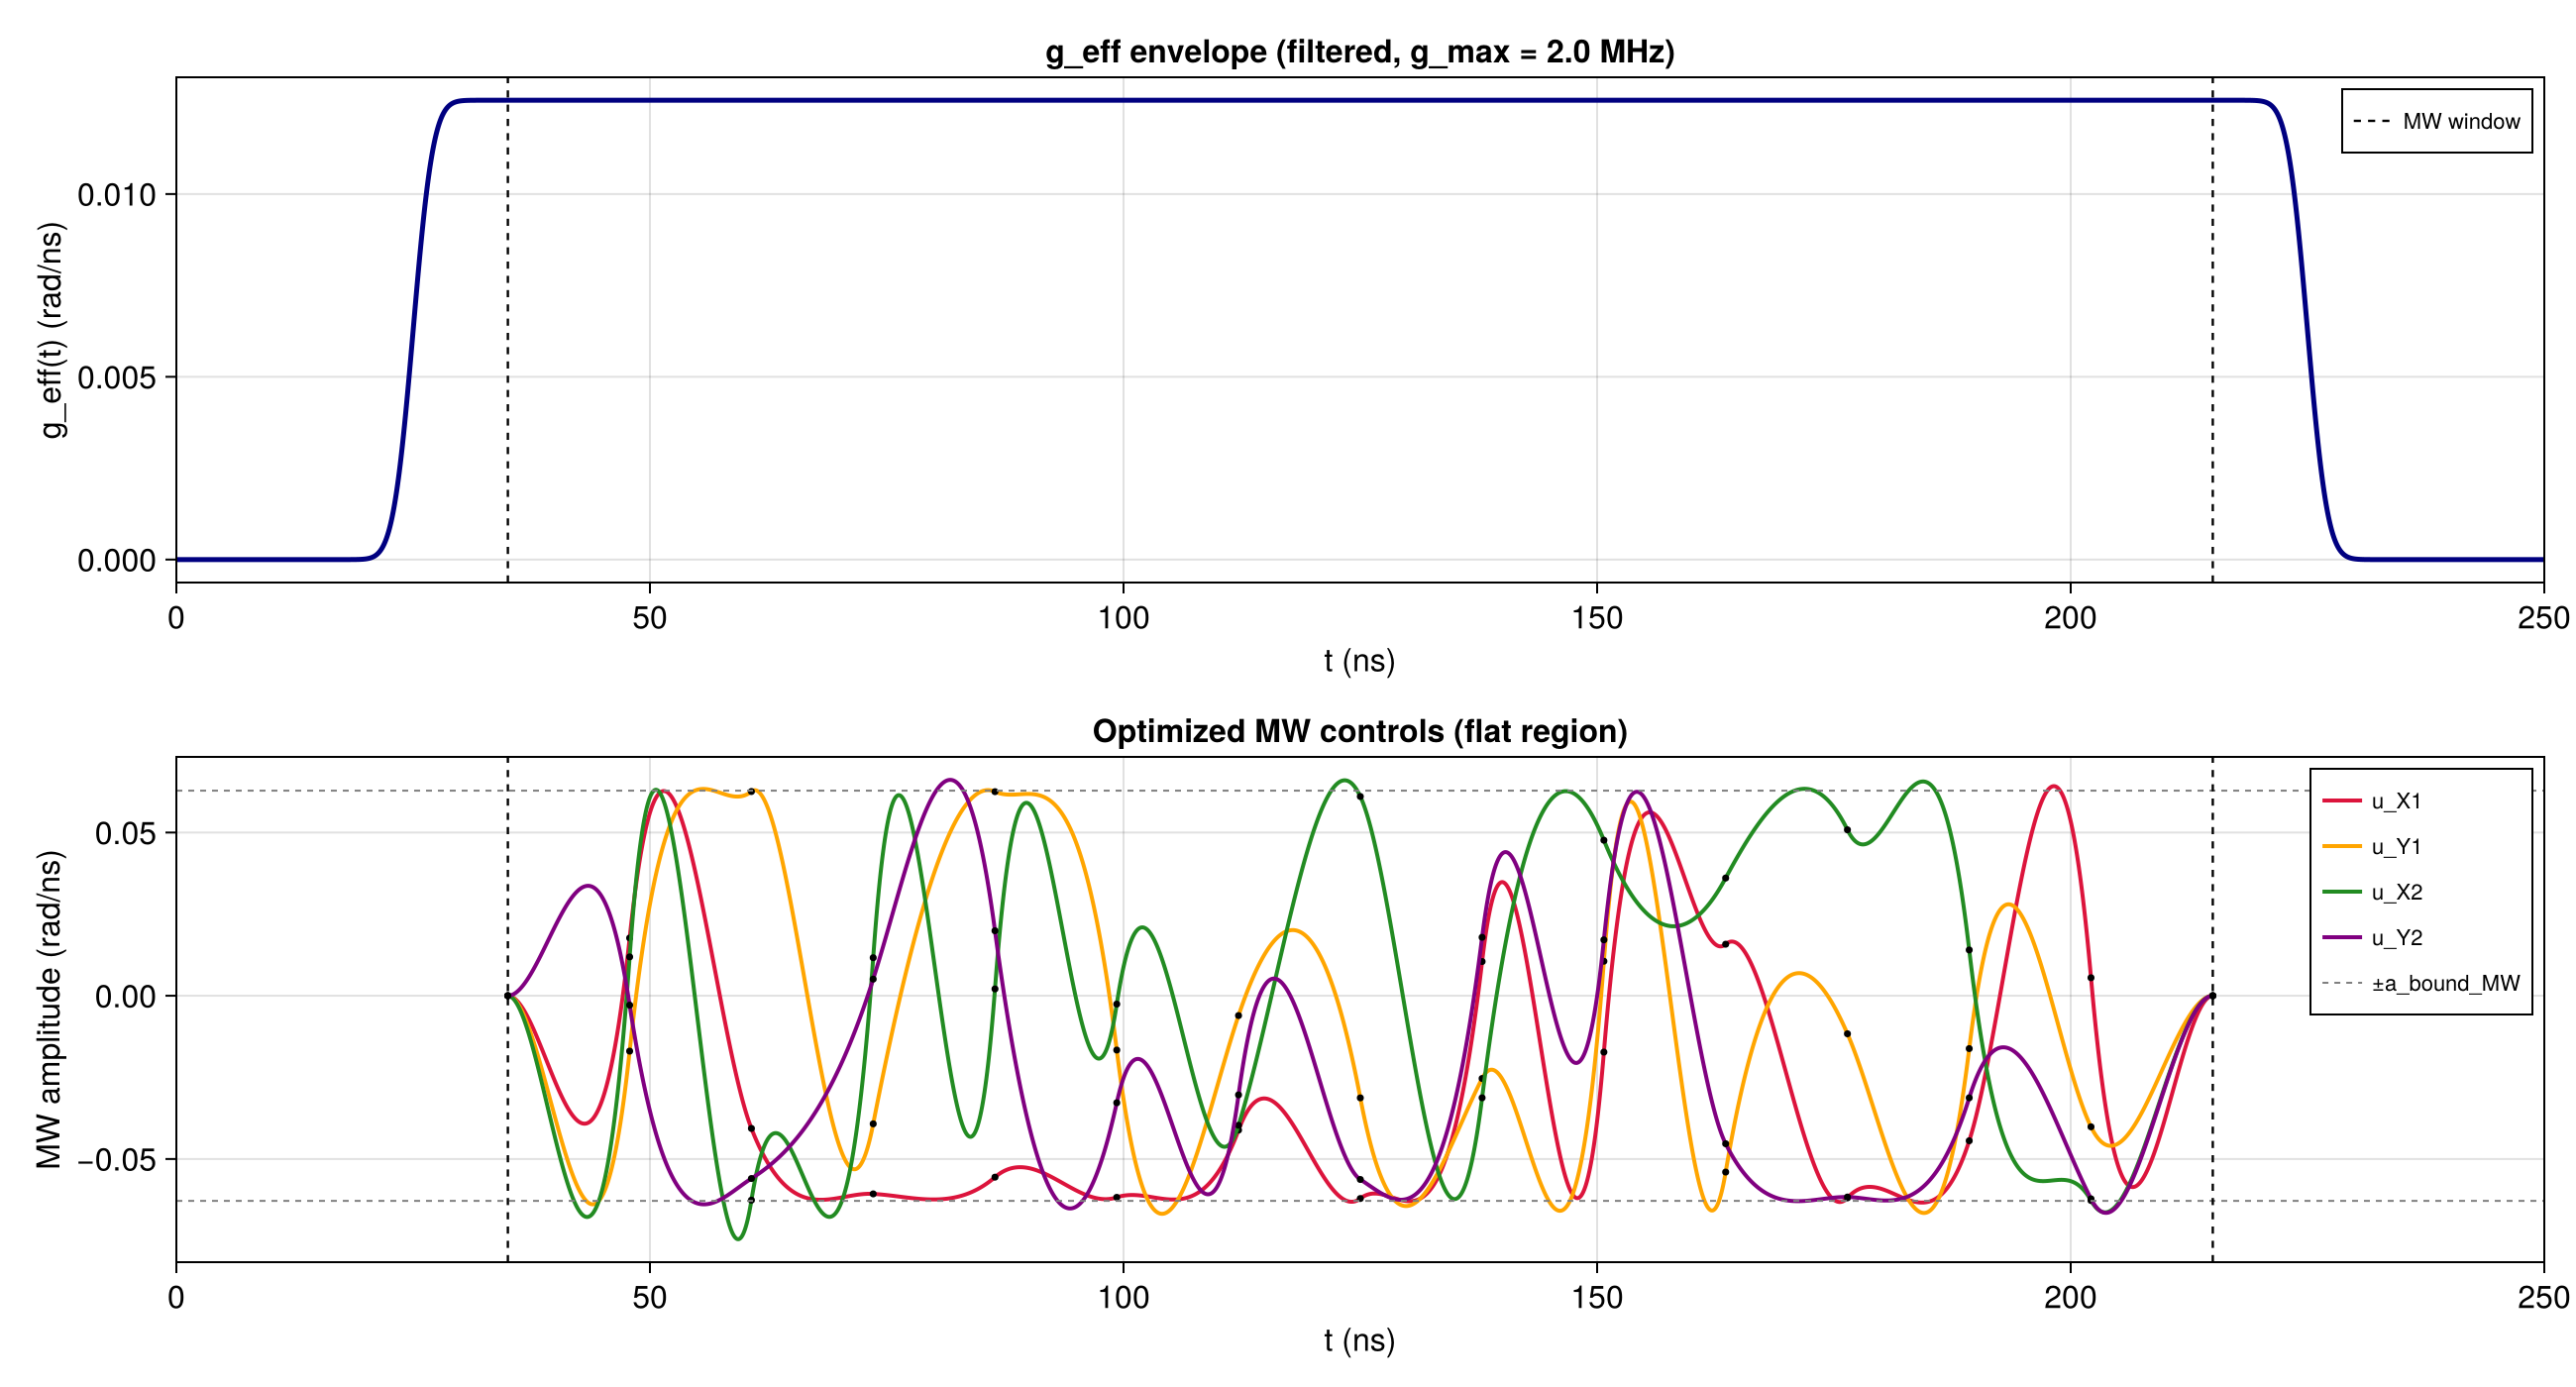

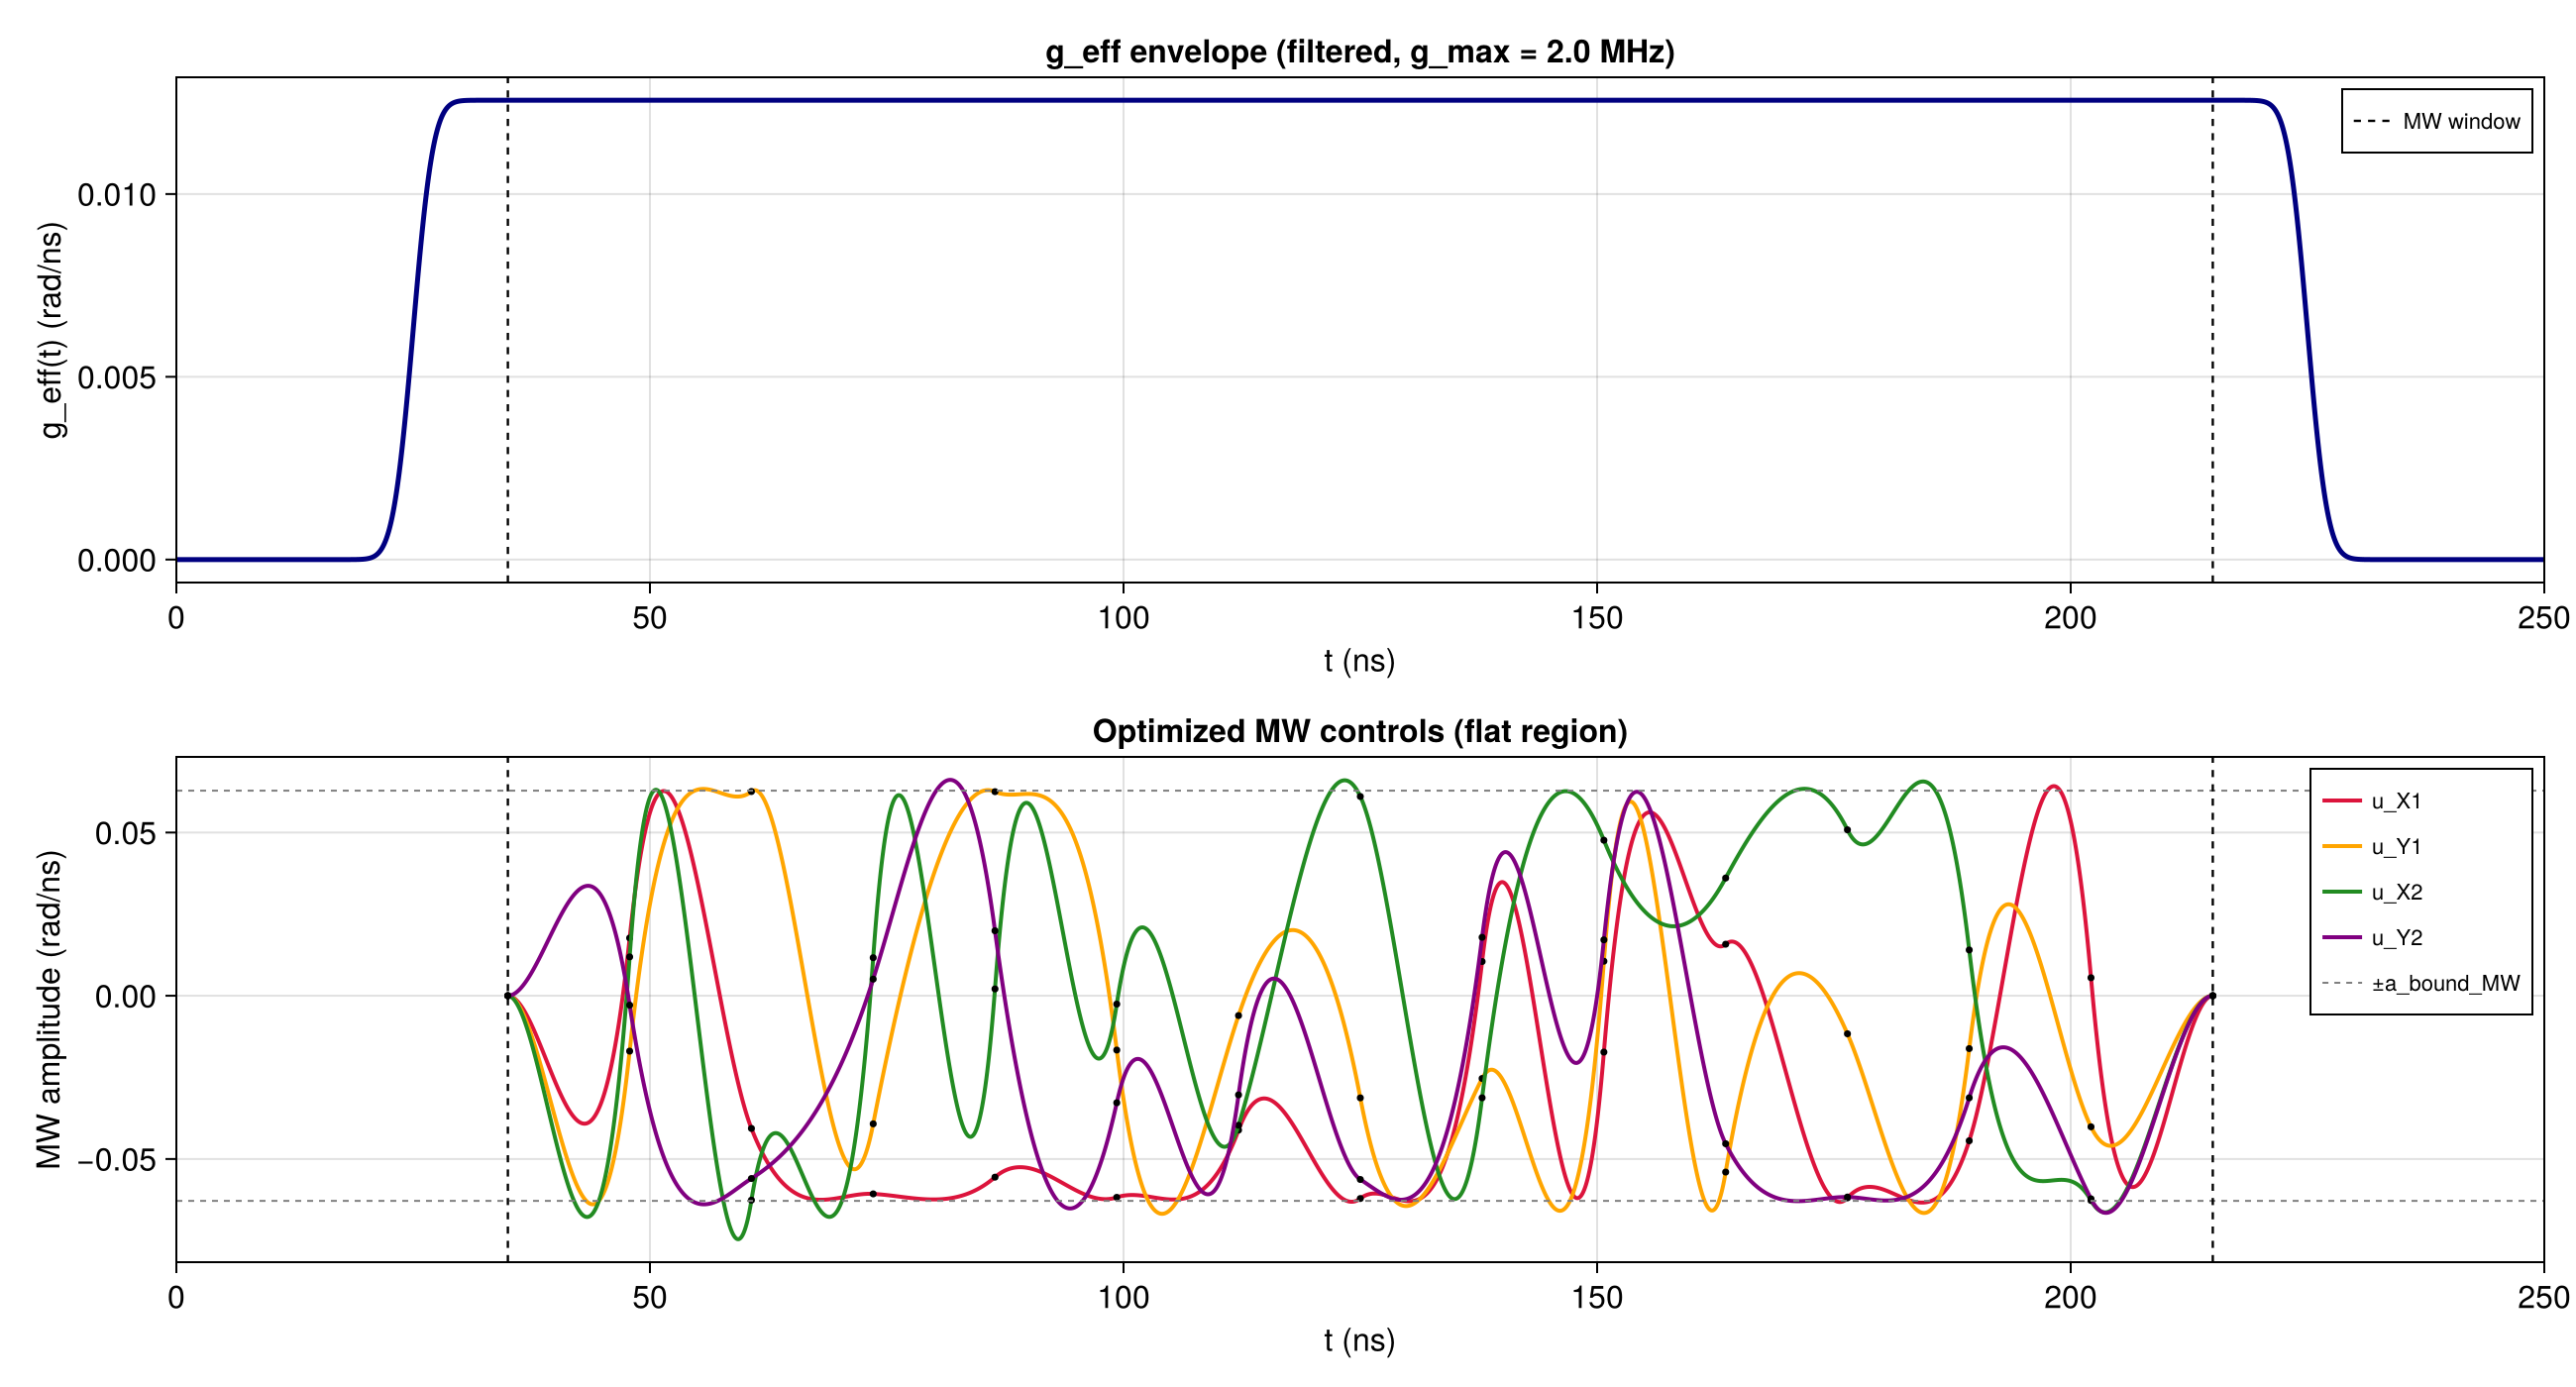

In [10]:
function _spline_fine(traj_local; N = 2000)
    ts_knots_loc = vec(traj_local[:t])
    us_knots_loc = traj_local[:u]
    du_knots_loc = traj_local[:du]
    pulse_loc    = CubicSplinePulse(us_knots_loc, du_knots_loc, ts_knots_loc)
    ts_fine_loc  = collect(LinRange(ts_knots_loc[1], ts_knots_loc[end], N))
    us_fine_loc  = sample(pulse_loc, ts_fine_loc)
    return ts_knots_loc, us_knots_loc, ts_fine_loc, us_fine_loc
end

ts_mw_knots, us_mw_knots, ts_mw_fine, us_mw_fine = _spline_fine(traj_robust)
T_MW_NS     = ts_mw_knots[end]
t_offset    = T_RISE + T_EDGE_MARK
mw_start_abs = t_offset
mw_end_abs   = t_offset + T_MW_NS
ts_mw_fine_abs  = ts_mw_fine  .+ t_offset
ts_mw_knots_abs = ts_mw_knots .+ t_offset

fig3 = Figure(size = (1300, 700), fontsize = 16)
ax_g = Axis(fig3[1, 1]; xlabel = "t (ns)", ylabel = "g_eff(t) (rad/ns)",
    title = @sprintf("g_eff envelope (filtered, g_max = %.1f MHz)", g_max_MHz))
lines!(ax_g, ts_env, g_phys_env; color = :navy, linewidth = 2.5)
vlines!(ax_g, [mw_start_abs, mw_end_abs];
    color = :black, linestyle = :dash, linewidth = 1.2, label = "MW window")
axislegend(ax_g; position = :rt, labelsize = 11)

ax_mw = Axis(fig3[2, 1]; xlabel = "t (ns)", ylabel = "MW amplitude (rad/ns)",
    title = "Optimized MW controls (flat region)")
labels      = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]
for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax_mw, ts_mw_fine_abs, vec(us_mw_fine[i, :]);
        color = col, linewidth = 2.0, label = lbl)
    scatter!(ax_mw, ts_mw_knots_abs, vec(us_mw_knots[i, :]);
        color = :black, markersize = 5)
end
hlines!(ax_mw, [a_bound_MW, -a_bound_MW]; linestyle = :dash, color = :gray,
    linewidth = 1.0, label = "±a_bound_MW")
vlines!(ax_mw, [mw_start_abs, mw_end_abs];
    color = :black, linestyle = :dash, linewidth = 1.2)
linkxaxes!(ax_g, ax_mw)
xlims!(ax_g, 0, T_TOTAL_NS)
axislegend(ax_mw; position = :rt, labelsize = 11)

save(joinpath(@__DIR__, "full_pulse_$(RUN_TAG).png"), fig3; px_per_unit = 4)
display(fig3)
fig3

MW spectrum at the constraint frequencies (vs ε_max = 1e-02):
  |Ω̂_1(+η_1=183.6 MHz)|² = 1.525e-03
  |Ω̂_2(+η_2=181.2 MHz)|² = 4.009e-04


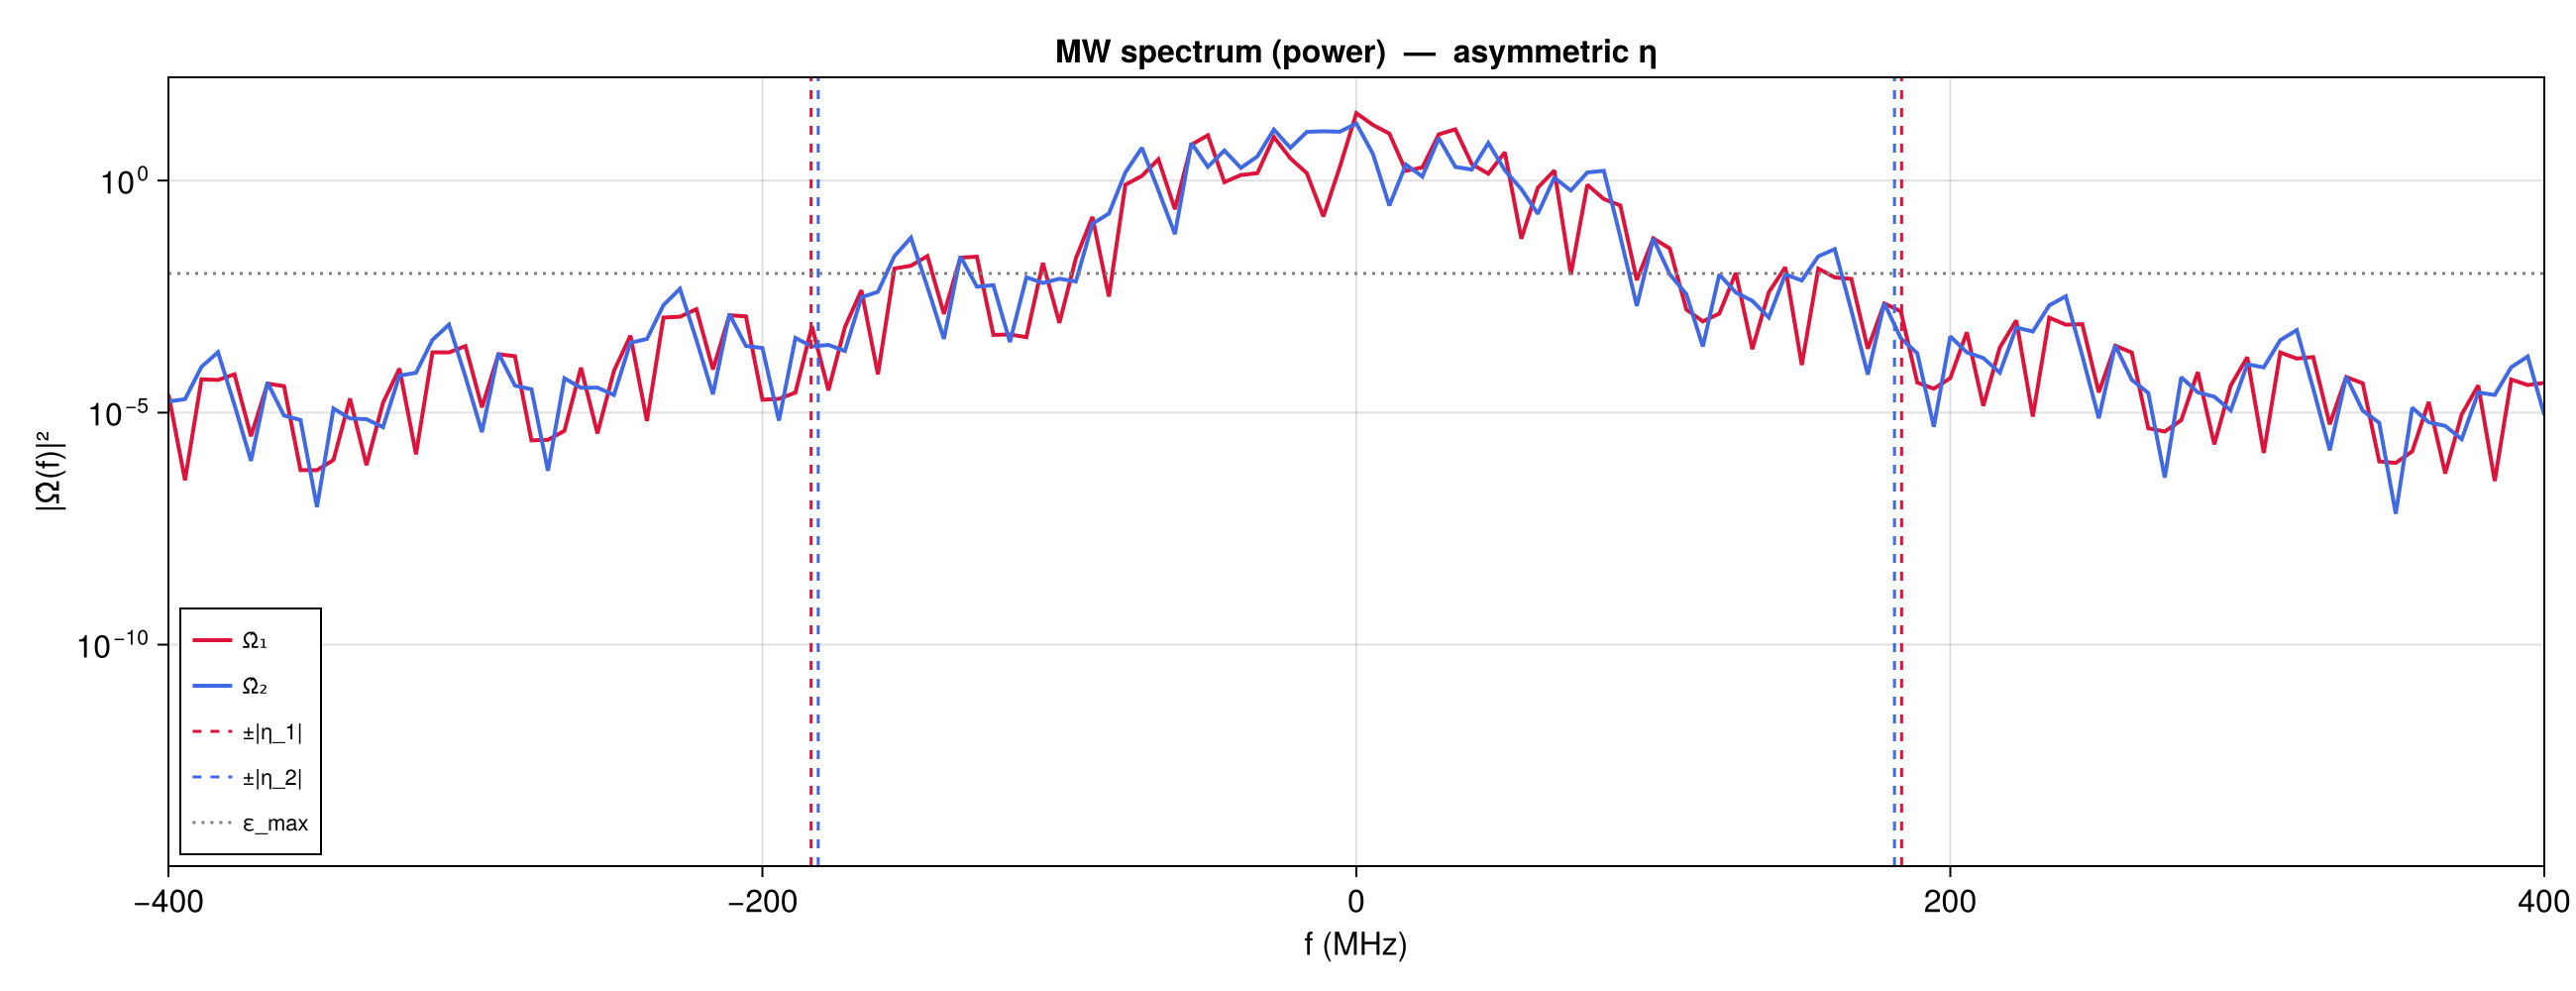

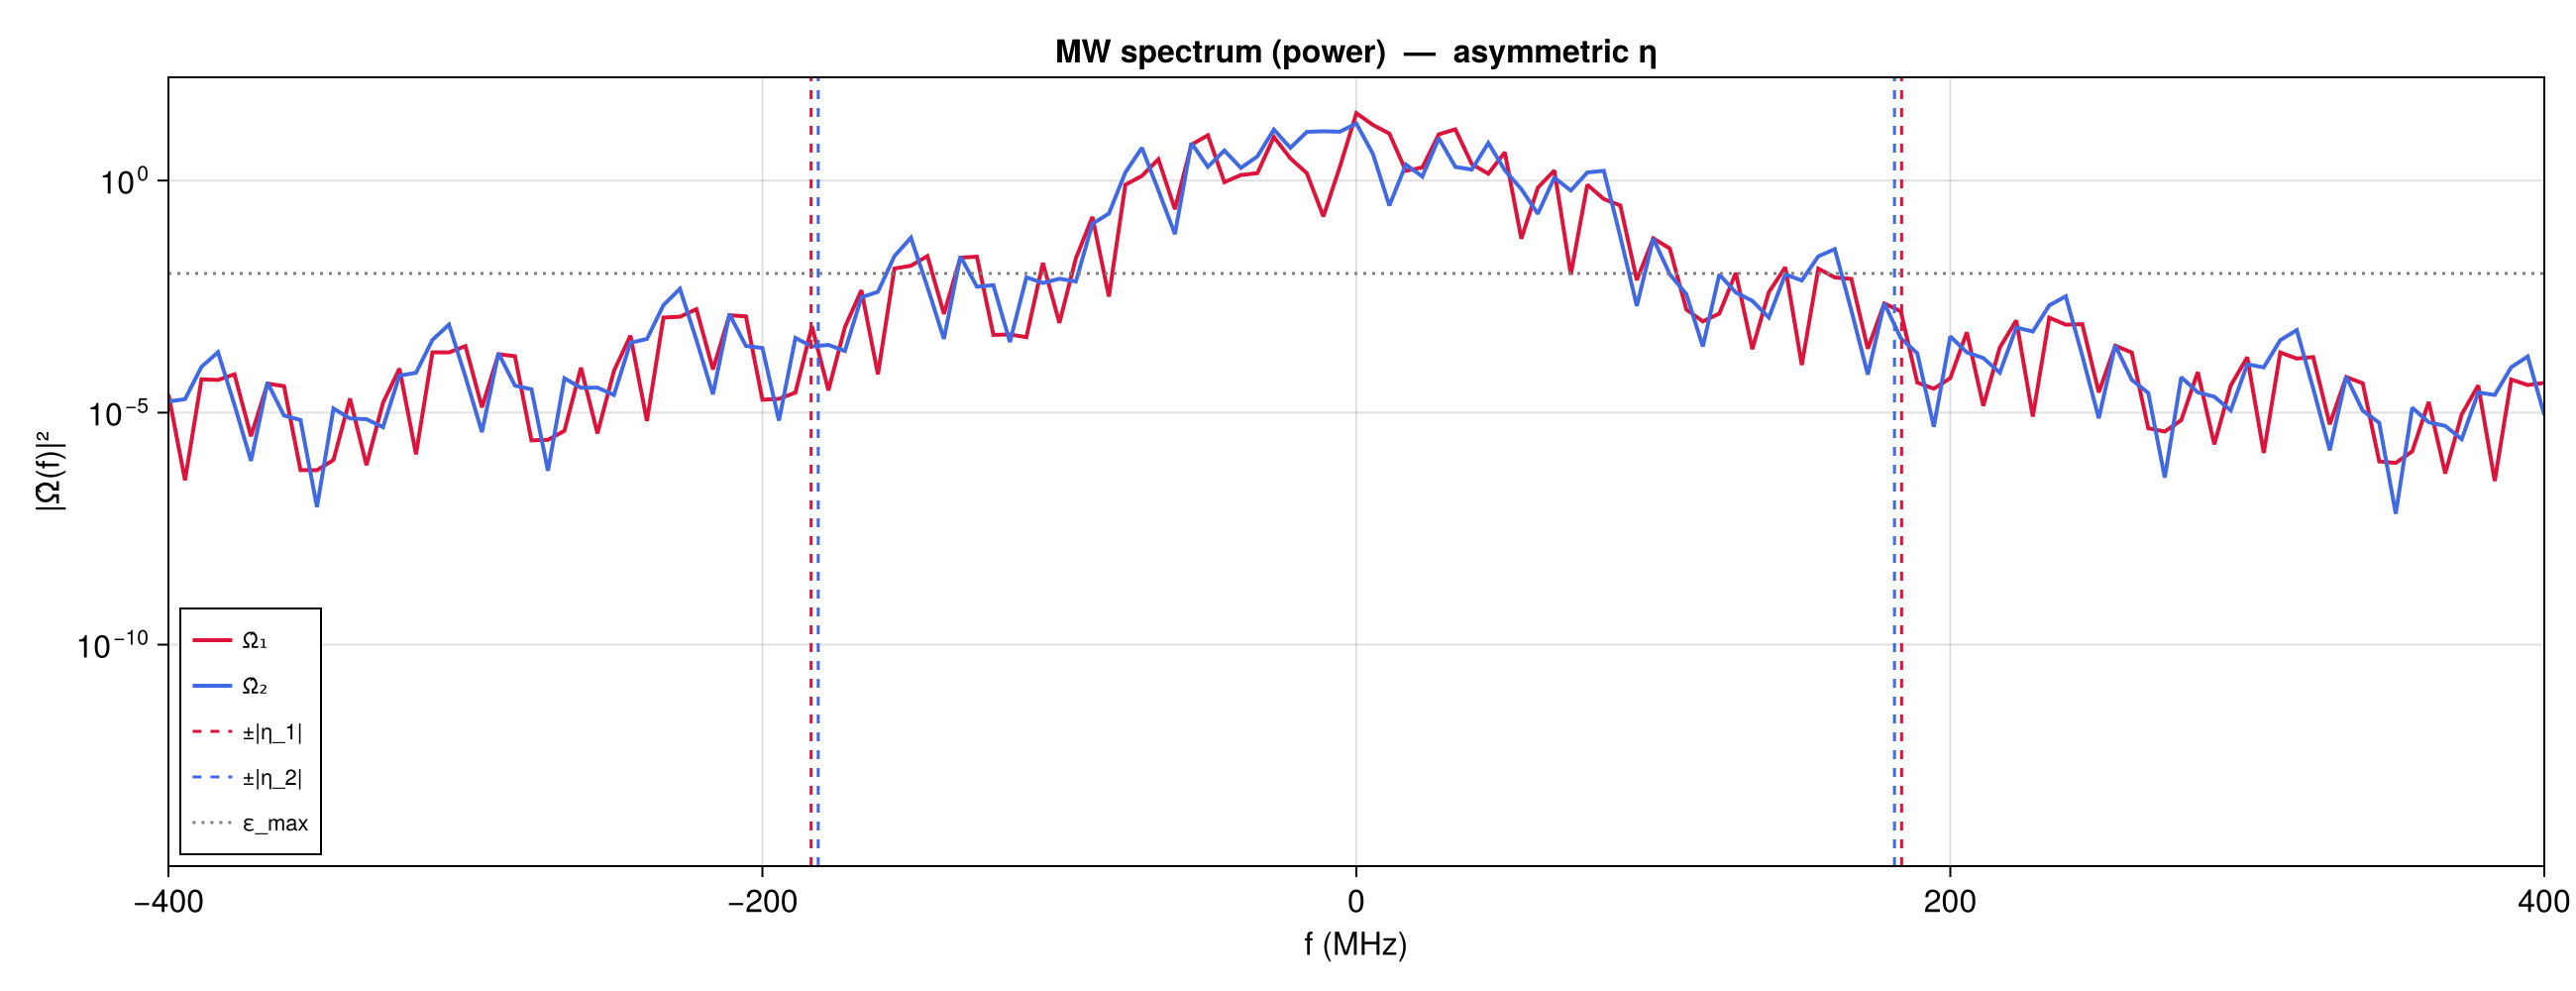

In [11]:
N_dense_mw = 16384
ts_dense   = collect(LinRange(0.0, T_MW_NS, N_dense_mw))
dt_dense   = ts_dense[2] - ts_dense[1]
pulse_loc  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
us_dense   = sample(pulse_loc, ts_dense)

Ω_1 = us_dense[1, :] .+ im .* us_dense[2, :]
Ω_2 = us_dense[3, :] .+ im .* us_dense[4, :]

Ω_1_hat = fftshift(fft(Ω_1)) .* dt_dense
Ω_2_hat = fftshift(fft(Ω_2)) .* dt_dense
fs_MHz_mw = fftshift(fftfreq(N_dense_mw, 1.0 / dt_dense)) .* 1e3

i_pos_1 = argmin(abs.(fs_MHz_mw .- η_1_MHz))
i_pos_2 = argmin(abs.(fs_MHz_mw .- η_2_MHz))
@printf("MW spectrum at the constraint frequencies (vs ε_max = %.0e):\n", ε_MAX)
@printf("  |Ω̂_1(+η_1=%.1f MHz)|² = %.3e\n", η_1_MHz, abs2(Ω_1_hat[i_pos_1]))
@printf("  |Ω̂_2(+η_2=%.1f MHz)|² = %.3e\n", η_2_MHz, abs2(Ω_2_hat[i_pos_2]))

fig6 = Figure(size = (1300, 500), fontsize = 16)
ax_f = Axis(fig6[1, 1]; xlabel = "f (MHz)", ylabel = "|Ω̂(f)|²",
    yscale = log10, title = "MW spectrum (power)  —  asymmetric η")
lines!(ax_f, fs_MHz_mw, max.(abs2.(Ω_1_hat), 1e-14); color = :crimson, linewidth = 2.0, label
= "Ω̂₁")
lines!(ax_f, fs_MHz_mw, max.(abs2.(Ω_2_hat), 1e-14); color = :royalblue, linewidth = 2.0,
label = "Ω̂₂")
vlines!(ax_f, [η_1_MHz, -η_1_MHz]; color = :crimson, linestyle = :dash, linewidth = 1.5, label
 = "±|η_1|")
vlines!(ax_f, [η_2_MHz, -η_2_MHz]; color = :royalblue, linestyle = :dash, linewidth = 1.5,
label = "±|η_2|")
hlines!(ax_f, [ε_MAX]; color = :gray, linestyle = :dot, linewidth = 1.5, label = "ε_max")
xlims!(ax_f, -400, 400)
axislegend(ax_f; position = :lb, labelsize = 11)

save(joinpath(@__DIR__, "mw_spectrum_$(RUN_TAG).png"), fig6; px_per_unit = 4)
display(fig6)
fig6


ZI @ ε=0:  default = 1.000000   robust = 0.999852
IZ @ ε=0:  default = 1.000000   robust = 0.999852
ZZ @ ε=0:  default = 1.000000   robust = 0.999852


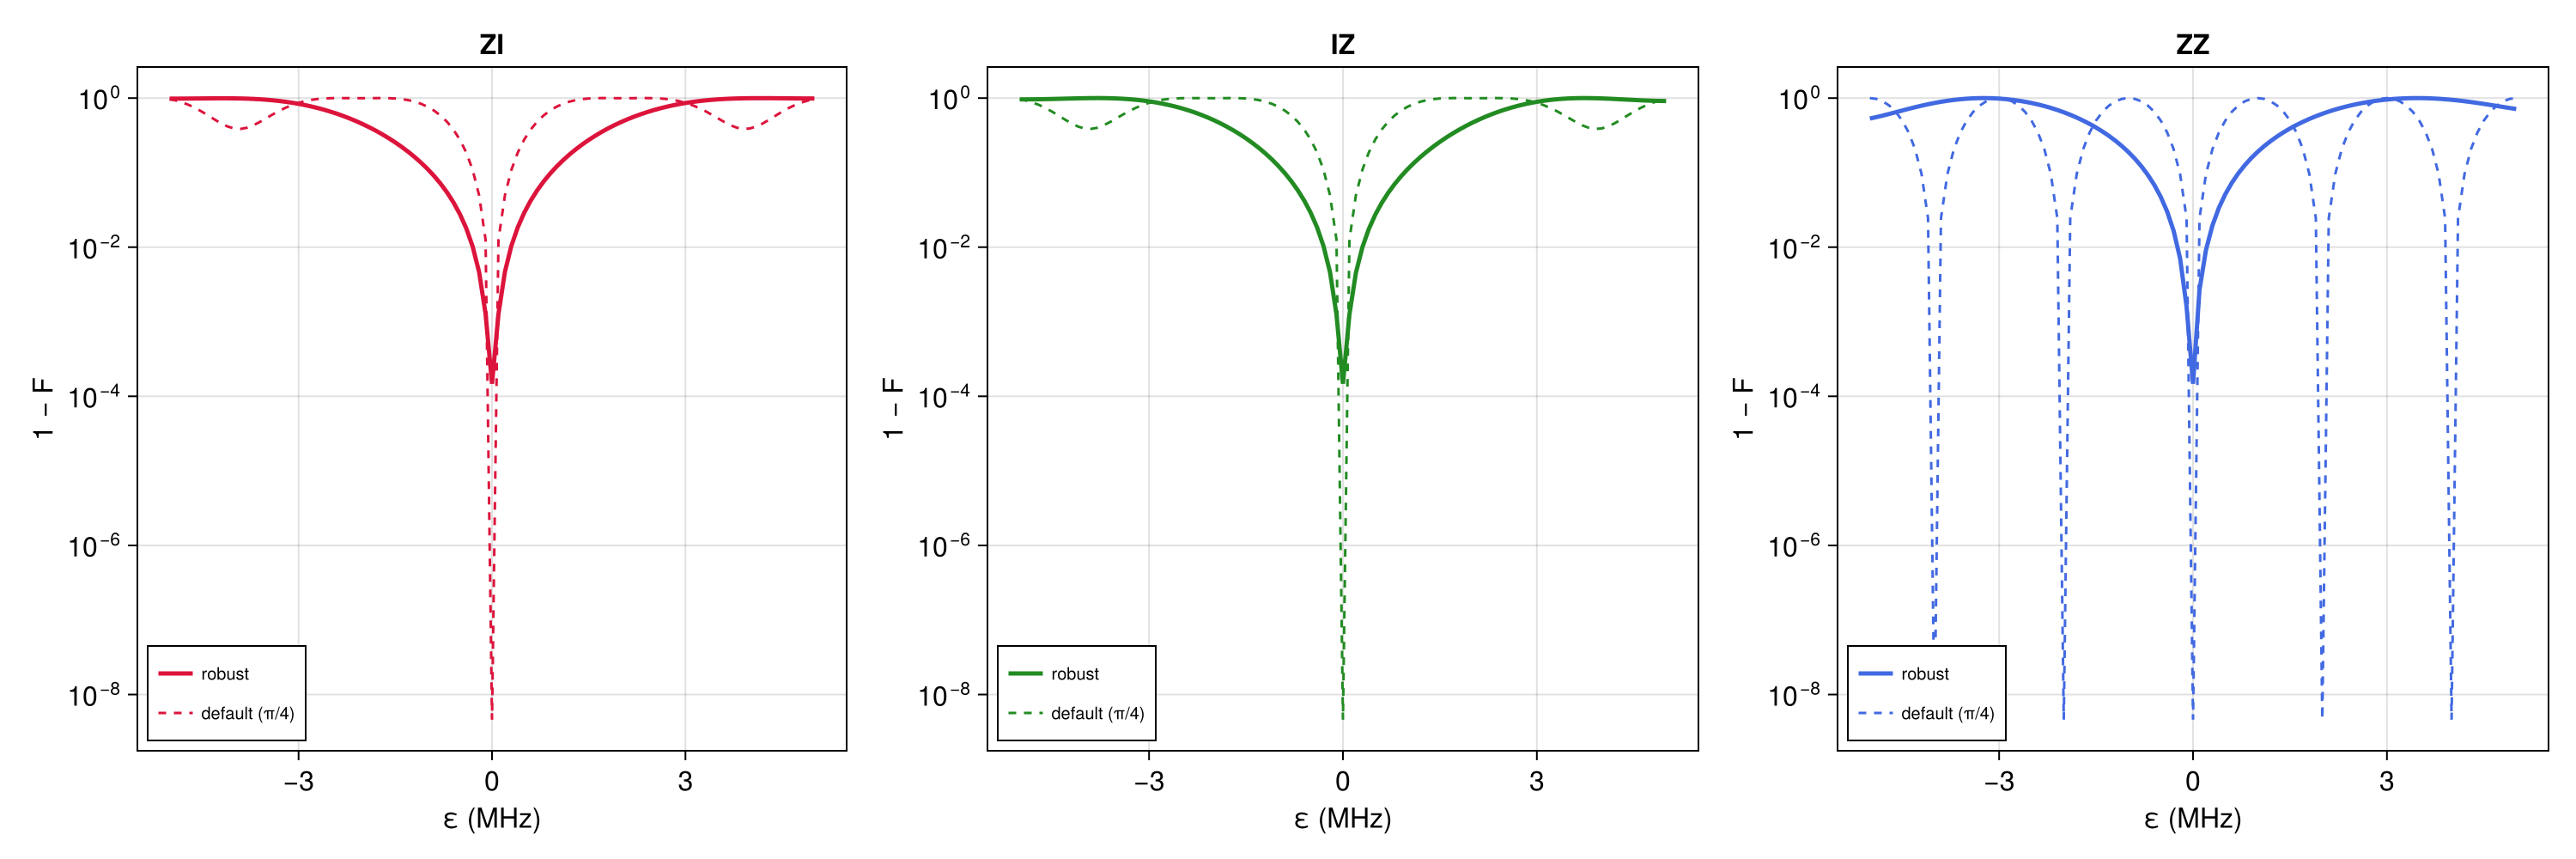

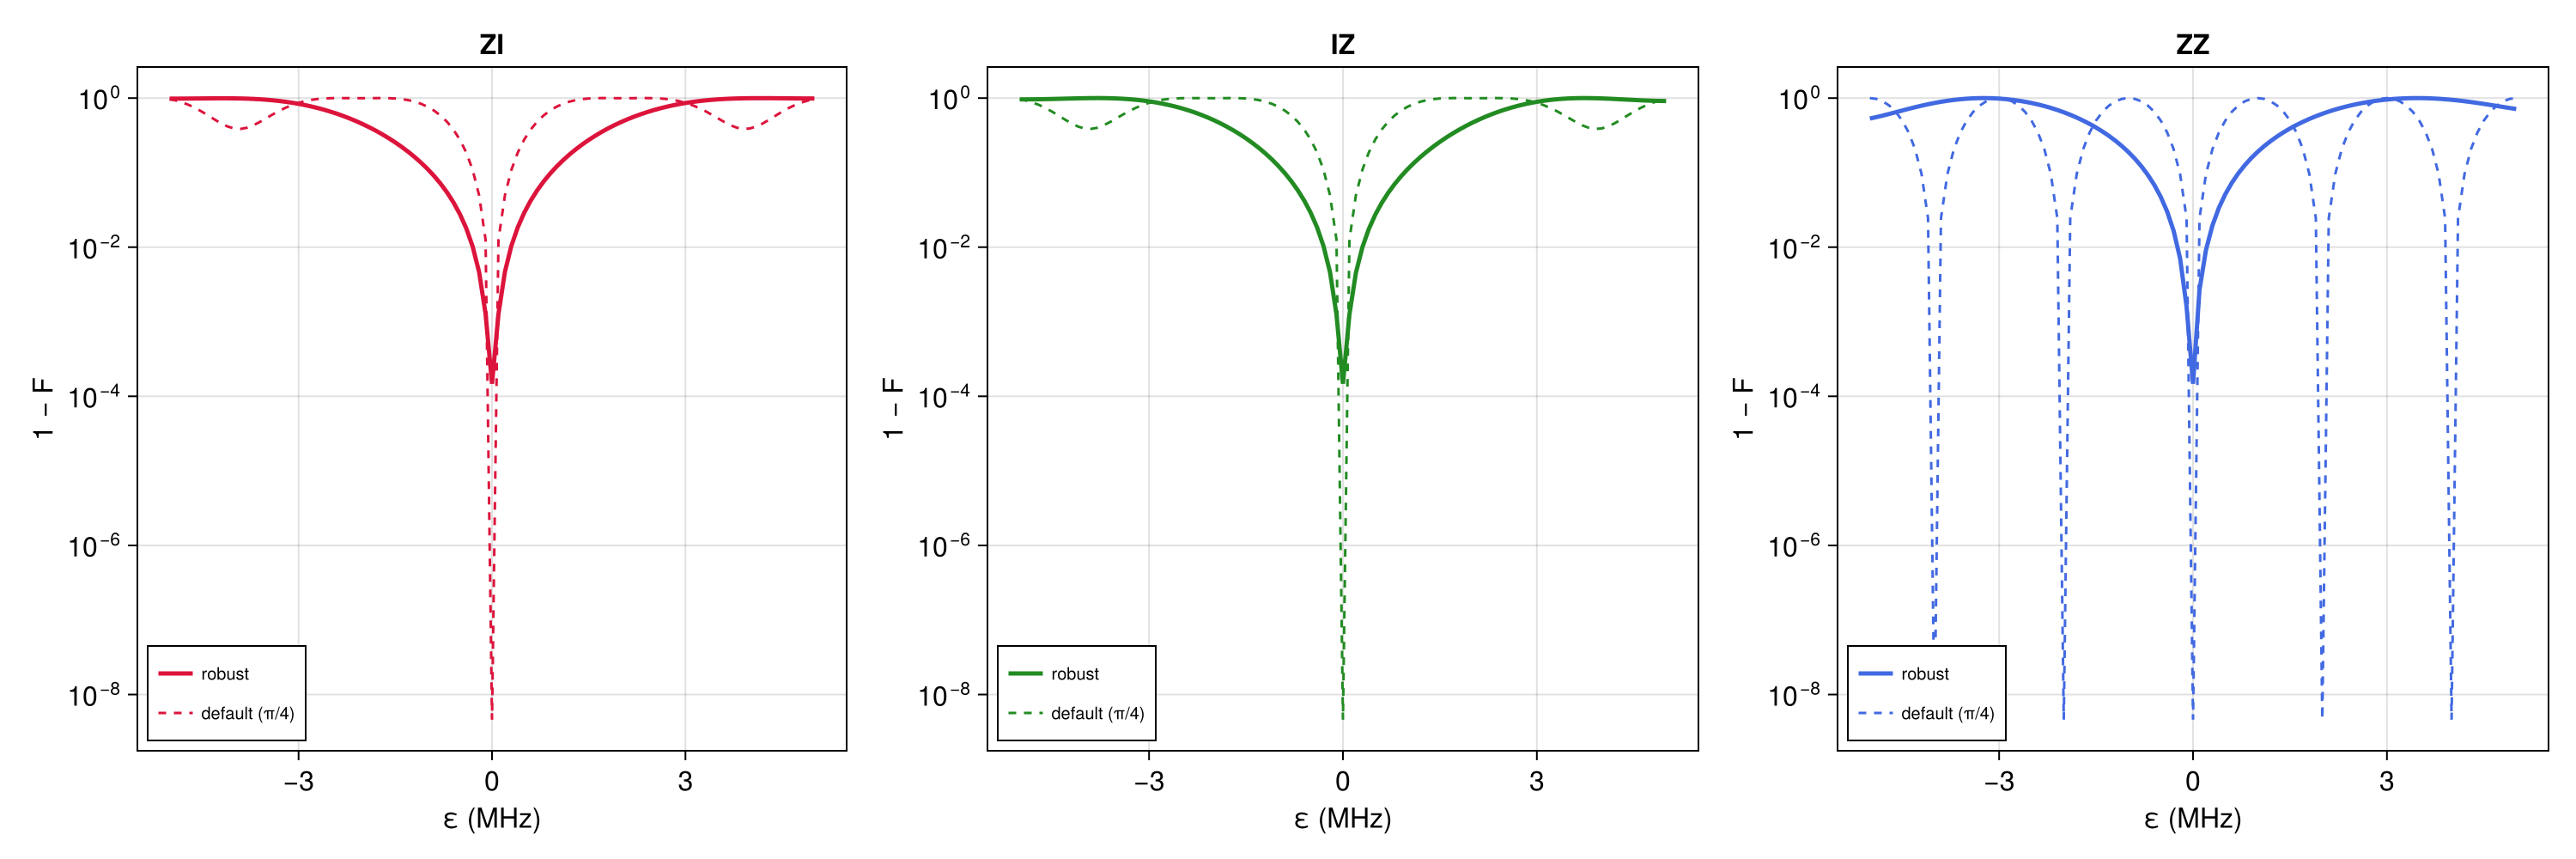

In [13]:
MW_END_ABS  = T_RISE + T_EDGE_MARK + T_MW_NS
N_EDGE_GRID = 800

function propagate_full_gate_2lvl(ε_val::Real, ε_op::AbstractMatrix; N_fine = 4000)
    ts_pre = collect(LinRange(0.0, T_RISE + T_EDGE_MARK, N_EDGE_GRID))
    g_pre  = [g_after_AWG[argmin(abs.(ts_env .- t))] * g_max_rad_per_ns for t in ts_pre]
    U_pre  = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_pre) - 1)
        dt_k  = ts_pre[k+1] - ts_pre[k]
        g_mid = 0.5 * (g_pre[k] + g_pre[k+1])
        H = g_mid * (XX + YY) + ε_val * ε_op
        U_pre = exp(-im * dt_k * H) * U_pre
    end

    ts_flat_grid = collect(LinRange(0.0, T_MW_NS, N_fine))
    pulse_local  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
    us_flat      = sample(pulse_local, ts_flat_grid)
    U_flat       = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_flat_grid) - 1)
        dt_k  = ts_flat_grid[k+1] - ts_flat_grid[k]
        u_mid = 0.5 .* (us_flat[:, k] .+ us_flat[:, k+1])
        H = g_flat * (XX + YY) +
        u_mid[1]*XI + u_mid[2]*YI +
        u_mid[3]*IX + u_mid[4]*IY +
        ε_val * ε_op
        U_flat = exp(-im * dt_k * H) * U_flat
    end

    ts_post = collect(LinRange(MW_END_ABS, T_TOTAL_NS, N_EDGE_GRID))
    g_post  = [g_after_AWG[argmin(abs.(ts_env .- t))] * g_max_rad_per_ns for t in ts_post]
    U_post  = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_post) - 1)
        dt_k  = ts_post[k+1] - ts_post[k]
        g_mid = 0.5 * (g_post[k] + g_post[k+1])
        H = g_mid * (XX + YY) + ε_val * ε_op
        U_post = exp(-im * dt_k * H) * U_post
    end
    return U_post * U_flat * U_pre
end

# Calibrated default: Gaussian-square with total area = π/4 (one iSWAP from drift)
function build_default_env(W_flat::Float64)
    ts_loc = collect(LinRange(0.0, T_TOTAL_NS, N_FINE))
    dt_loc = ts_loc[2] - ts_loc[1]
    t_c    = T_TOTAL_NS / 2
    g_sq   = [(t_c - W_flat/2 ≤ t ≤ t_c + W_flat/2) ? g_max_env : 0.0 for t in ts_loc]
    g_a    = gaussian_lowpass(g_sq, dt_loc, σ_f_anh_MHz)
    g_b    = gaussian_lowpass(g_a,  dt_loc, σ_f_AWG_MHz)
    return ts_loc, g_b
end
function default_area(W_flat::Float64)
    ts_loc, g_b = build_default_env(W_flat)
    return sum(g_b) * (ts_loc[2] - ts_loc[1]) * g_max_rad_per_ns
end
lo, hi = 0.0, T_TOTAL_NS * 0.9
for _ in 1:80
    mid = (lo + hi) / 2
    default_area(mid) < π/4 ? (lo = mid) : (hi = mid)
end
W_DEF = (lo + hi) / 2
ts_def, g_def_norm = build_default_env(W_DEF)
g_def_phys = g_def_norm .* g_max_rad_per_ns

function propagate_default_2lvl(ε_val::Real, ε_op::AbstractMatrix)
    U = Matrix{ComplexF64}(I, 4, 4)
    @inbounds for k in 1:(length(ts_def) - 1)
        dt_k  = ts_def[k+1] - ts_def[k]
        g_mid = 0.5 * (g_def_phys[k] + g_def_phys[k+1])
        H = g_mid * (XX + YY) + ε_val * ε_op
        U = exp(-im * dt_k * H) * U
    end
    return U
end

εs_MHz_2q = collect(LinRange(-5.0, 5.0, 101))
εs_rad    = 2π .* εs_MHz_2q .* 1e-3
err_channels = [(:ZI, ZI), (:IZ, IZ), (:ZZ, ZZ)]

F_def_vs_eps = Dict{Symbol, Vector{Float64}}()
F_rob_vs_eps = Dict{Symbol, Vector{Float64}}()
for (name, op) in err_channels
    F_def = Float64[]; F_rob = Float64[]
    for ε in εs_rad
        U_def = propagate_default_2lvl(ε, op)
        U_rob = propagate_full_gate_2lvl(ε, op)
        push!(F_def, abs2(tr(U_iSWAP' * U_def)) / 16)
        push!(F_rob, abs2(tr(U_iSWAP' * U_rob)) / 16)
    end
    F_def_vs_eps[name] = F_def
    F_rob_vs_eps[name] = F_rob
    i0 = argmin(abs.(εs_MHz_2q))
    @printf("%s @ ε=0:  default = %.6f   robust = %.6f\n",
        string(name), F_def[i0], F_rob[i0])
end

ch_colors = Dict(:ZI => :crimson, :IZ => :forestgreen, :ZZ => :royalblue)
fig4 = Figure(size = (1500, 500), fontsize = 16)
ax_ZI = Axis(fig4[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F", yscale = log10, title = "ZI")
ax_IZ = Axis(fig4[1, 2]; xlabel = "ε (MHz)", ylabel = "1 − F", yscale = log10, title = "IZ")
ax_ZZ = Axis(fig4[1, 3]; xlabel = "ε (MHz)", ylabel = "1 − F", yscale = log10, title = "ZZ")
axes_F = Dict(:ZI => ax_ZI, :IZ => ax_IZ, :ZZ => ax_ZZ)
for (name, _) in err_channels
    ax = axes_F[name]; c = ch_colors[name]
    lines!(ax, εs_MHz_2q, max.(1 .- F_rob_vs_eps[name], 1e-12);
        color = c, linewidth = 2.5, label = "robust")
    lines!(ax, εs_MHz_2q, max.(1 .- F_def_vs_eps[name], 1e-12);
        color = c, linewidth = 1.5, linestyle = :dash, label = "default (π/4)")
    axislegend(ax; position = :lb, labelsize = 10)
end
save(joinpath(@__DIR__, "eps_sweep_2lvl_$(RUN_TAG).png"), fig4; px_per_unit = 4)
display(fig4)
fig4

In [ ]:
# 3-lvl ε-sweep with asymmetric anharmonicities

  # 9-dim operators (non-const so cell can be re-run)
  I_9     = Matrix{ComplexF64}(I, 9, 9)
  I_3lvl  = Matrix{ComplexF64}(I, 3, 3)
  a_3     = ComplexF64[0 1 0; 0 0 sqrt(2); 0 0 0]
  a1_9    = kron(a_3, I_3lvl)
  a2_9    = kron(I_3lvl, a_3)
  n1_9    = a1_9' * a1_9
  n2_9    = a2_9' * a2_9
  XI_9    = a1_9 + a1_9'
  YI_9    = im * (a1_9' - a1_9)
  IX_9    = a2_9 + a2_9'
  IY_9    = im * (a2_9' - a2_9)
  exch_9  = XI_9 * IX_9 + YI_9 * IY_9   # = 2·(a₁†a₂ + a₁a₂†), matches g·(XX+YY)

  # Per-qubit anharmonicity (asymmetric)
  H_anh_9 = (η_1_rad_neg / 2) * n1_9 * (n1_9 - I_9) +
            (η_2_rad_neg / 2) * n2_9 * (n2_9 - I_9)

  QSUB = [1, 2, 4, 5]

  function propagate_full_gate_3lvl(ε_val::Real, ε_op_9::AbstractMatrix; N_fine = 4000)
      ts_pre = collect(LinRange(0.0, T_RISE + T_EDGE_MARK, N_EDGE_GRID))
      g_pre  = [g_after_AWG[argmin(abs.(ts_env .- t))] * g_max_rad_per_ns for t in ts_pre]
      U_pre  = Matrix{ComplexF64}(I, 9, 9)
      @inbounds for k in 1:(length(ts_pre) - 1)
          dt_k  = ts_pre[k+1] - ts_pre[k]
          g_mid = 0.5 * (g_pre[k] + g_pre[k+1])
          H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
          U_pre = exp(-im * dt_k * H) * U_pre
      end

      ts_flat_grid = collect(LinRange(0.0, T_MW_NS, N_fine))
      pulse_local  = CubicSplinePulse(traj_robust[:u], traj_robust[:du], vec(traj_robust[:t]))
      us_flat      = sample(pulse_local, ts_flat_grid)
      U_flat = Matrix{ComplexF64}(I, 9, 9)
      @inbounds for k in 1:(length(ts_flat_grid) - 1)
          dt_k  = ts_flat_grid[k+1] - ts_flat_grid[k]
          u_mid = 0.5 .* (us_flat[:, k] .+ us_flat[:, k+1])
          H = H_anh_9 + g_flat * exch_9 +
              u_mid[1]*XI_9 + u_mid[2]*YI_9 +
              u_mid[3]*IX_9 + u_mid[4]*IY_9 +
              ε_val * ε_op_9
          U_flat = exp(-im * dt_k * H) * U_flat
      end

      ts_post = collect(LinRange(MW_END_ABS, T_TOTAL_NS, N_EDGE_GRID))
      g_post  = [g_after_AWG[argmin(abs.(ts_env .- t))] * g_max_rad_per_ns for t in ts_post]
      U_post  = Matrix{ComplexF64}(I, 9, 9)
      @inbounds for k in 1:(length(ts_post) - 1)
          dt_k  = ts_post[k+1] - ts_post[k]
          g_mid = 0.5 * (g_post[k] + g_post[k+1])
          H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
          U_post = exp(-im * dt_k * H) * U_post
      end
      return U_post * U_flat * U_pre
  end

  function propagate_default_3lvl_with_eps(ε_val::Real, ε_op_9::AbstractMatrix)
      U = Matrix{ComplexF64}(I, 9, 9)
      @inbounds for k in 1:(length(ts_def) - 1)
          dt_k  = ts_def[k+1] - ts_def[k]
          g_mid = 0.5 * (g_def_phys[k] + g_def_phys[k+1])
          H = H_anh_9 + g_mid * exch_9 + ε_val * ε_op_9
          U = exp(-im * dt_k * H) * U
      end
      return U
  end

  # ε = 0 quick check
  U_3lvl_0   = propagate_full_gate_3lvl(0.0, zeros(ComplexF64, 9, 9))
  U_sub_0    = U_3lvl_0[QSUB, QSUB]
  F_3_raw_0  = abs2(tr(U_iSWAP' * U_sub_0)) / 16
  L_3_0      = 1 - real(tr(U_sub_0' * U_sub_0)) / 4

  U_def_3lvl   = propagate_default_3lvl_with_eps(0.0, zeros(ComplexF64, 9, 9))
  U_def_sub    = U_def_3lvl[QSUB, QSUB]
  F_3_def_raw  = abs2(tr(U_iSWAP' * U_def_sub)) / 16
  L_3_def      = 1 - real(tr(U_def_sub' * U_def_sub)) / 4

  @printf("\n=== 3-lvl at ε = 0 (asymmetric η) ===\n")
  @printf("Robust:   F_3 = %.8f   (1−F = %.3e)   L_3 = %.3e\n", F_3_raw_0, 1 - F_3_raw_0, L_3_0)
  @printf("Default:  F_3 = %.8f   (1−F = %.3e)   L_3 = %.3e\n", F_3_def_raw, 1 - F_3_def_raw,
  L_3_def)

  # Sweep against n̂_1, n̂_2, n̂_1·n̂_2 (transmon-physical noise generators)
  err_channels_3lvl = [(:n̂1, n1_9), (:n̂2, n2_9), (:n̂1n̂2, n1_9 * n2_9)]
  F3_rob_vs_eps = Dict{Symbol, Vector{Float64}}()
  L3_rob_vs_eps = Dict{Symbol, Vector{Float64}}()
  F3_def_vs_eps = Dict{Symbol, Vector{Float64}}()
  L3_def_vs_eps = Dict{Symbol, Vector{Float64}}()

  for (name, op) in err_channels_3lvl
      Fr = Float64[]; Lr = Float64[]
      Fd = Float64[]; Ld = Float64[]
      for ε in εs_rad
          U_r = propagate_full_gate_3lvl(ε, op)
          U_d = propagate_default_3lvl_with_eps(ε, op)
          U_rs = U_r[QSUB, QSUB]
          U_ds = U_d[QSUB, QSUB]
          push!(Fr, abs2(tr(U_iSWAP' * U_rs)) / 16)
          push!(Lr, 1 - real(tr(U_rs' * U_rs)) / 4)
          push!(Fd, abs2(tr(U_iSWAP' * U_ds)) / 16)
          push!(Ld, 1 - real(tr(U_ds' * U_ds)) / 4)
      end
      F3_rob_vs_eps[name] = Fr; L3_rob_vs_eps[name] = Lr
      F3_def_vs_eps[name] = Fd; L3_def_vs_eps[name] = Ld
      i0 = argmin(abs.(εs_MHz_2q))
      @printf("3-lvl %s @ ε=0:  robust F=%.6f L=%.3e   default F=%.6f L=%.3e\n",
          string(name), Fr[i0], Lr[i0], Fd[i0], Ld[i0])
  end



=== 3-lvl at ε = 0 (asymmetric η) ===
Robust:   F_3 = 0.99140094   (1−F = 8.599e-03)   L_3 = 2.830e-03
Default:  F_3 = 0.99659257   (1−F = 3.407e-03)   L_3 = 4.341e-05
3-lvl n̂1 @ ε=0:  robust F=0.991401 L=2.830e-03   default F=0.996593 L=4.341e-05
3-lvl n̂2 @ ε=0:  robust F=0.991401 L=2.830e-03   default F=0.996593 L=4.341e-05
3-lvl n̂1n̂2 @ ε=0:  robust F=0.991401 L=2.830e-03   default F=0.996593 L=4.341e-05


Base.Meta.ParseError: ParseError:
# Error @ /Users/andrewkamen/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/robust_iswap_computational/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X30sZmlsZQ==.jl:143:3

  axes_F = Dict(:n̂1 => ax_n1, :n̂2 => ax_n2, :n̂1n̂2 => ax_n1n2)
# └────────────────────────────────────────────────────────┘ ── Expected `)`

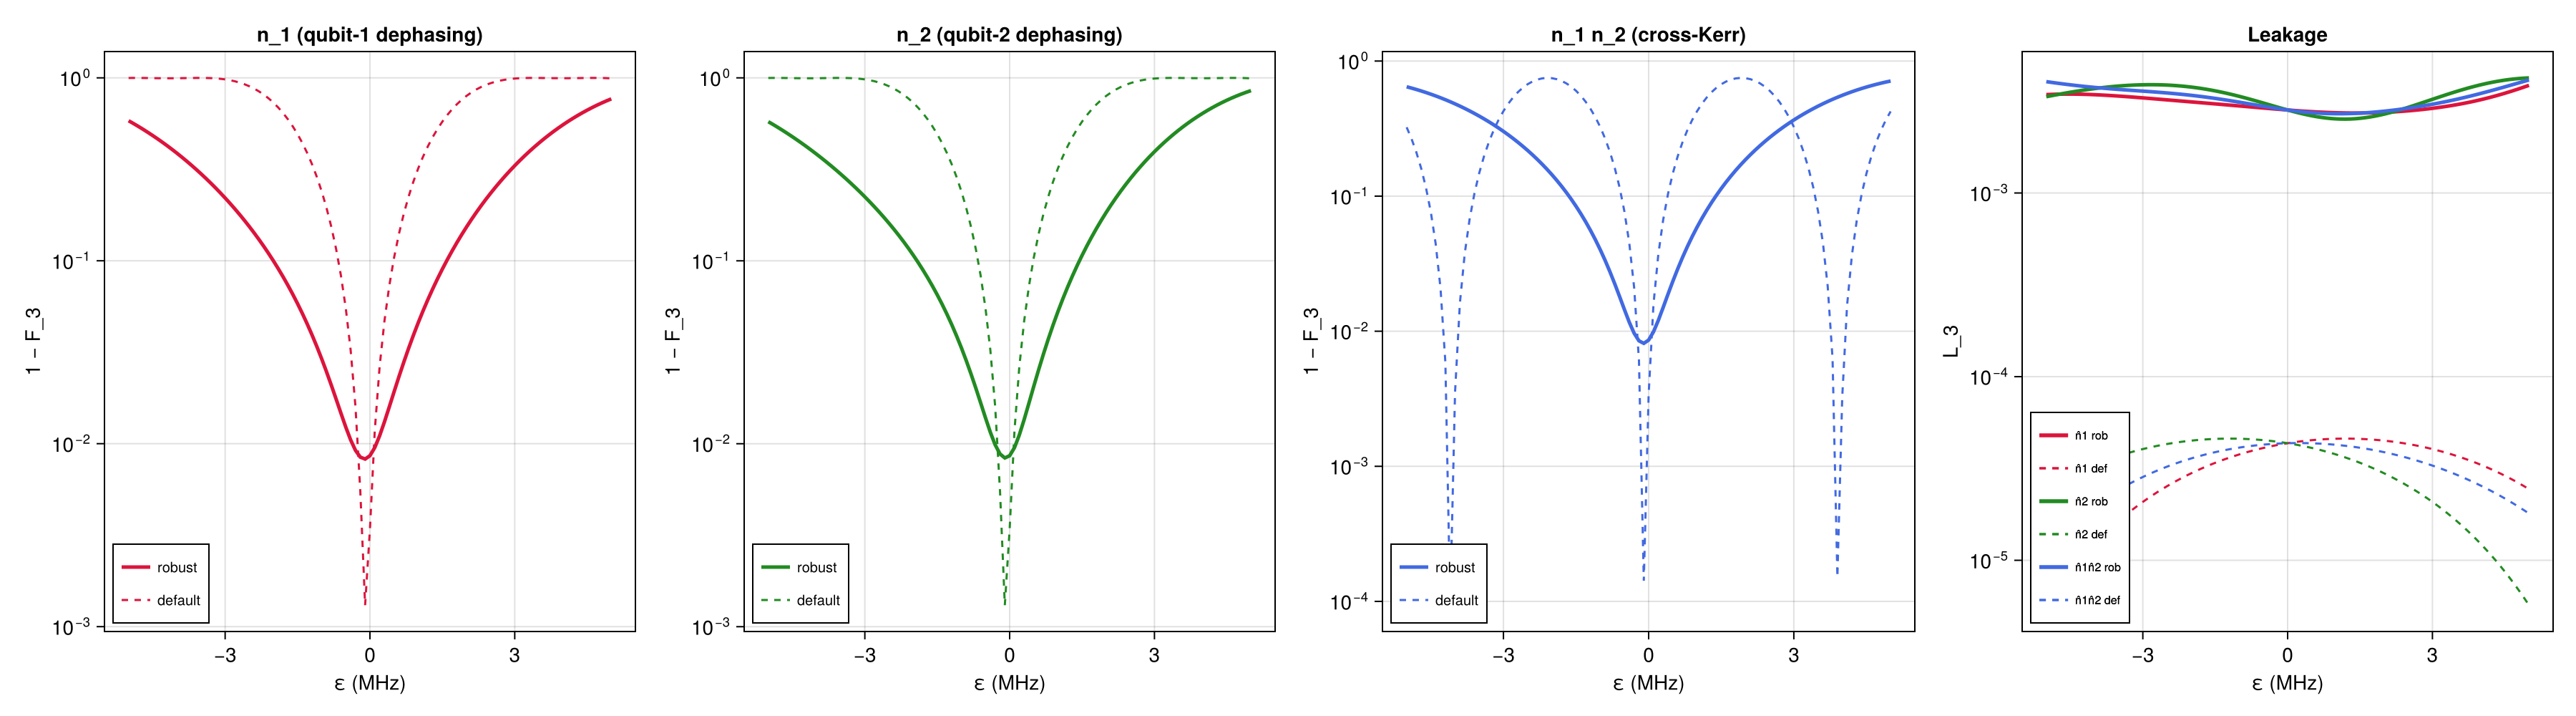

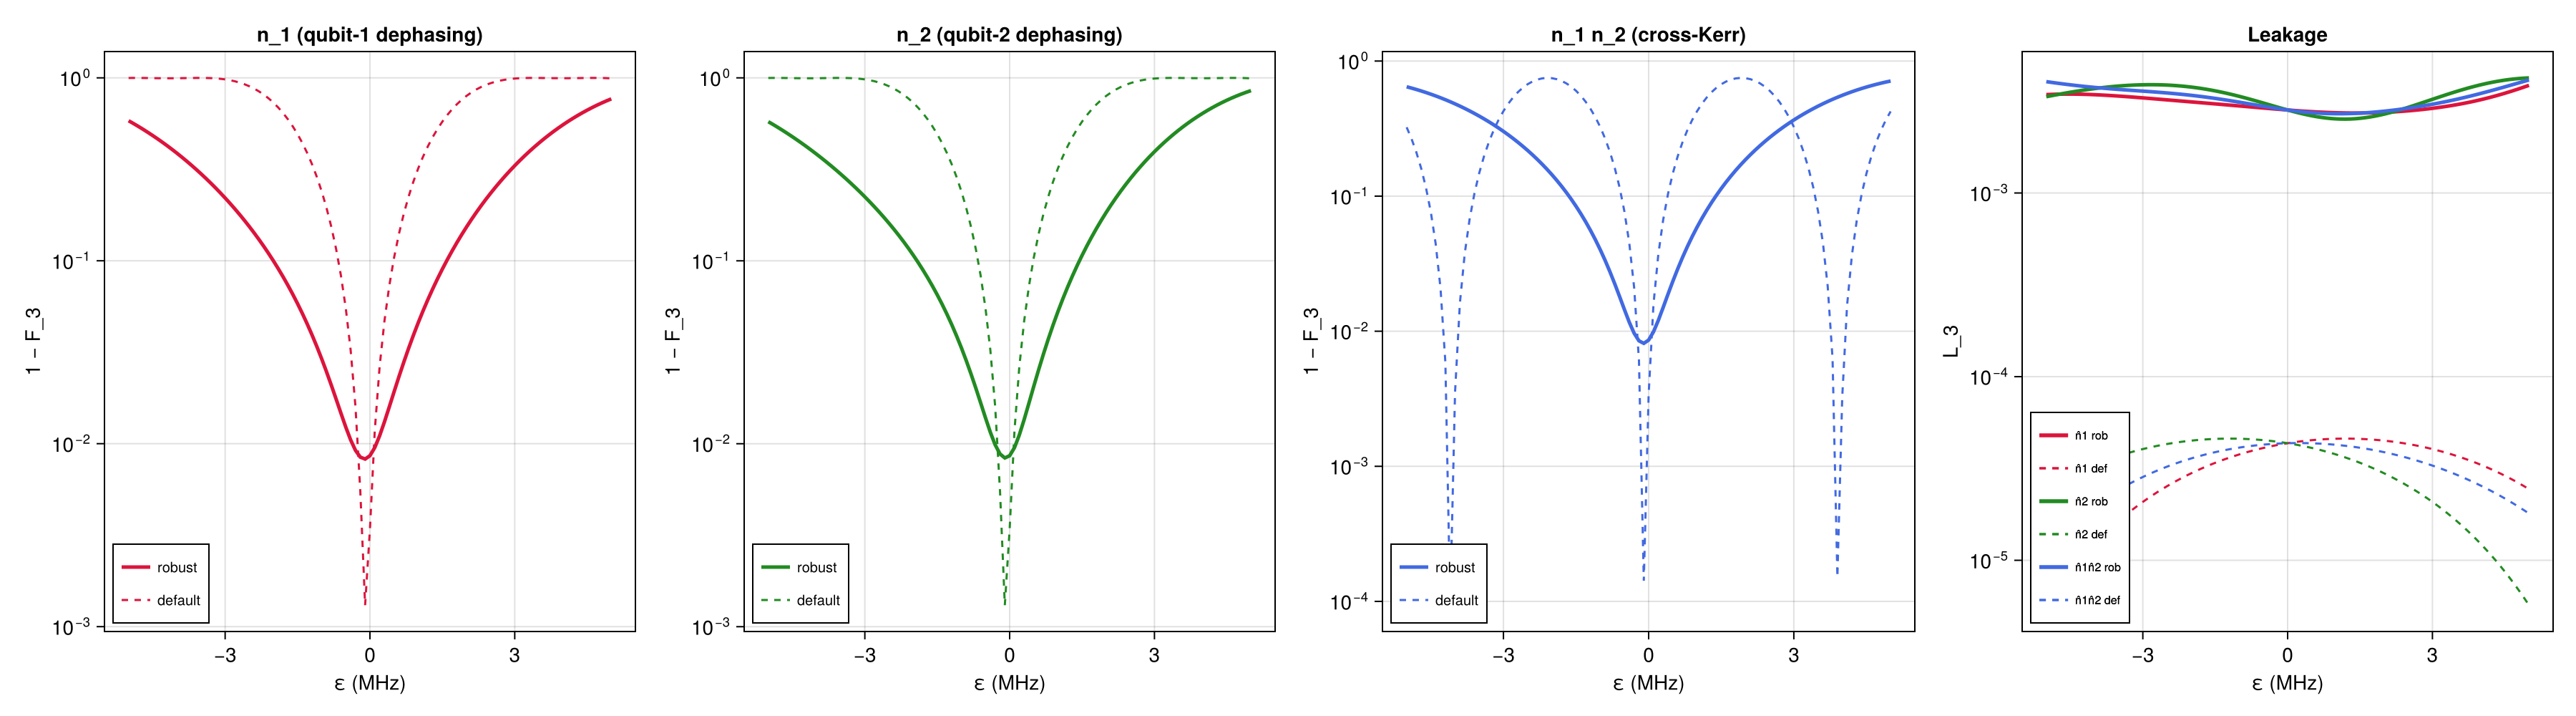

In [16]:

ch_colors_3lvl = Dict(:n̂1 => :crimson, :n̂2 => :forestgreen, :n̂1n̂2 => :royalblue)

fig5 = Figure(size = (1800, 500), fontsize = 14)
ax_n1   = Axis(fig5[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title =
"n_1 (qubit-1 dephasing)")
ax_n2   = Axis(fig5[1, 2]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title =
"n_2 (qubit-2 dephasing)")
ax_n1n2 = Axis(fig5[1, 3]; xlabel = "ε (MHz)", ylabel = "1 − F_3", yscale = log10, title =
"n_1 n_2 (cross-Kerr)")
ax_L    = Axis(fig5[1, 4]; xlabel = "ε (MHz)", ylabel = "L_3",    yscale = log10, title =
"Leakage")
axes_F = Dict(:n̂1 => ax_n1, :n̂2 => ax_n2, :n̂1n̂2 => ax_n1n2)

for (name, _) in err_channels_3lvl
    ax = axes_F[name]
    c  = ch_colors_3lvl[name]
    lines!(ax, εs_MHz_2q, max.(1 .- F3_rob_vs_eps[name], 1e-12); color = c, linewidth = 2.5,
label = "robust")
    lines!(ax, εs_MHz_2q, max.(1 .- F3_def_vs_eps[name], 1e-12); color = c, linewidth = 1.5,
linestyle = :dash, label = "default")
    axislegend(ax; position = :lb, labelsize = 10)
    lines!(ax_L, εs_MHz_2q, max.(L3_rob_vs_eps[name], 1e-12); color = c, linewidth = 2.5,
label = "$(string(name)) rob")
    lines!(ax_L, εs_MHz_2q, max.(L3_def_vs_eps[name], 1e-12); color = c, linewidth = 1.5,
linestyle = :dash, label = "$(string(name)) def")
end
axislegend(ax_L; position = :lb, labelsize = 8)

axislegend(ax_L; position = :lb, labelsize = 8)

save(joinpath(@__DIR__, "eps_sweep_3lvl_$(RUN_TAG).png"), fig5; px_per_unit = 4)
display(fig5)
fig5

## Next

This trajectory is the warm-start for the 3-qubit optimization. Save format mirrors the symmetric `iswap_pulse_construction.ipynb` so the polish-script loader works with minimal changes (just point `TRAJ_PATH` and read per-qubit η).

For honest 3-lvl verification of this 2Q gate before scaling to 3Q, use the polish-script propagator with per-qubit anharmonicities in `H_anh_9`:

```julia
H_anh_9 = (η_1_rad_neg / 2) * (n1_9 * (n1_9 - I_9)) +
          (η_2_rad_neg / 2) * (n2_9 * (n2_9 - I_9))
```

That replaces the symmetric `H_anh_9 = (η_rad / 2) * (n1_9*(n1_9-I_9) + n2_9*(n2_9-I_9))`. Everything else stays.